# Ноутбук с разведочным анализом данных и созданием новых признаков

## 1. Импорт бибилиотек и конфигурация проекта

In [111]:
# Создадим словарь конфигураций.

CONFIG = {
    # Константы
    "DEV_MODE": False,
    "DEV_SAMPLE_SIZE": 100000,
    "RANDOM_STATE": 42,
    # Целевая переменная 
    "TARGET": "Цена",
    # Колонки с категориальными признаками
    "CAT_COLS": ['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']
}

In [112]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pyarrow
import phik
from phik.report import plot_correlation_matrix

In [113]:
df = pd.read_parquet("../data/processed/train_cleaned.parquet")

## 2. Проверка на адекватность

In [114]:
df.head(5)

,Название машины,Год,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,...,Цвет,Комплектация,Тип кузова,Марка,Город,Регион,Макро-регион,Владельцы,Есть особые отметки,Цена
456584,Toyota Corolla Spacio,2003.0,1.5,бензин,109.0,АКПП,передний,228000.0,правый,2.0,...,серый,1.5 X G edition,минивэн,toyota,Якутск,Республика Саха,ДФО,4,0,650000.0
476657,Toyota Corolla,2007.0,1.6,бензин,124.0,РКПП,передний,237000.0,левый,10.0,...,голубой,1.6 MultiMode Престиж,седан,toyota,Рославль,Смоленская область,ЦФО,2,0,800000.0
436621,Subaru Legacy,1994.0,2.2,бензин,136.0,АКПП,4WD,200000.0,левый,1.0,...,бордовый,2.2 AT Classic Super-Station,универсал,subaru,Москва,Москва,Москва,4,1,100000.0
479257,Toyota Camry,2007.0,3.5,бензин,277.0,АКПП,передний,319801.0,левый,7.0,...,черный,3.5 AT Luxe,седан,toyota,Иркутск,Иркутская область,СФО,4,0,790000.0
340053,Mitsubishi Colt,1996.0,1.3,бензин,75.0,АКПП,передний,246000.0,левый,5.0,...,зеленый,1.3 AT GLX,хэтчбек 3 дв.,mitsubishi,Солнечногорск,Московская область,ЦФО,3,0,250000.0


In [115]:
df.shape

(458473, 21)

In [116]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']


C:\Users\Степан\AppData\Local\Temp\ipykernel_8828\1233978785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 3. Анализ целевой переменной

<Axes: xlabel='Цена', ylabel='Count'>

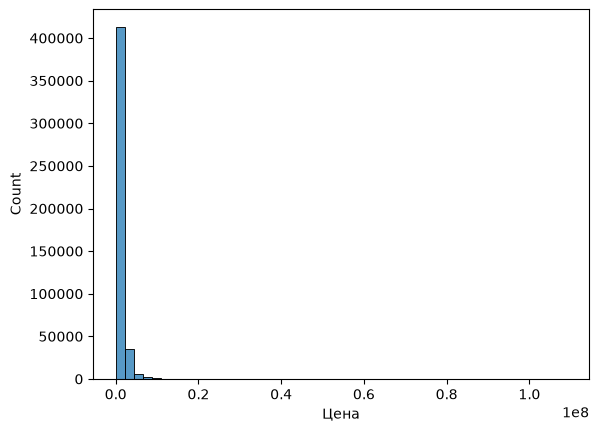

In [117]:
sns.histplot(data=df, x=CONFIG["TARGET"], bins=50)

Заметим, что распределение целевой переменной обладает сильной правосторонней асимметрией (длинным правым хвостом). В дальнейшем планируется прологарифмировать таргет, чтобы приблизить его распределение к нормальному (симметричному)

## 4. Одномерный анализ признаков

### 4.1 Числовые признаки

In [118]:
print(num_cols)

['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Поколение', 'Рестайлинг', 'Владельцы', 'Есть особые отметки', 'Цена']


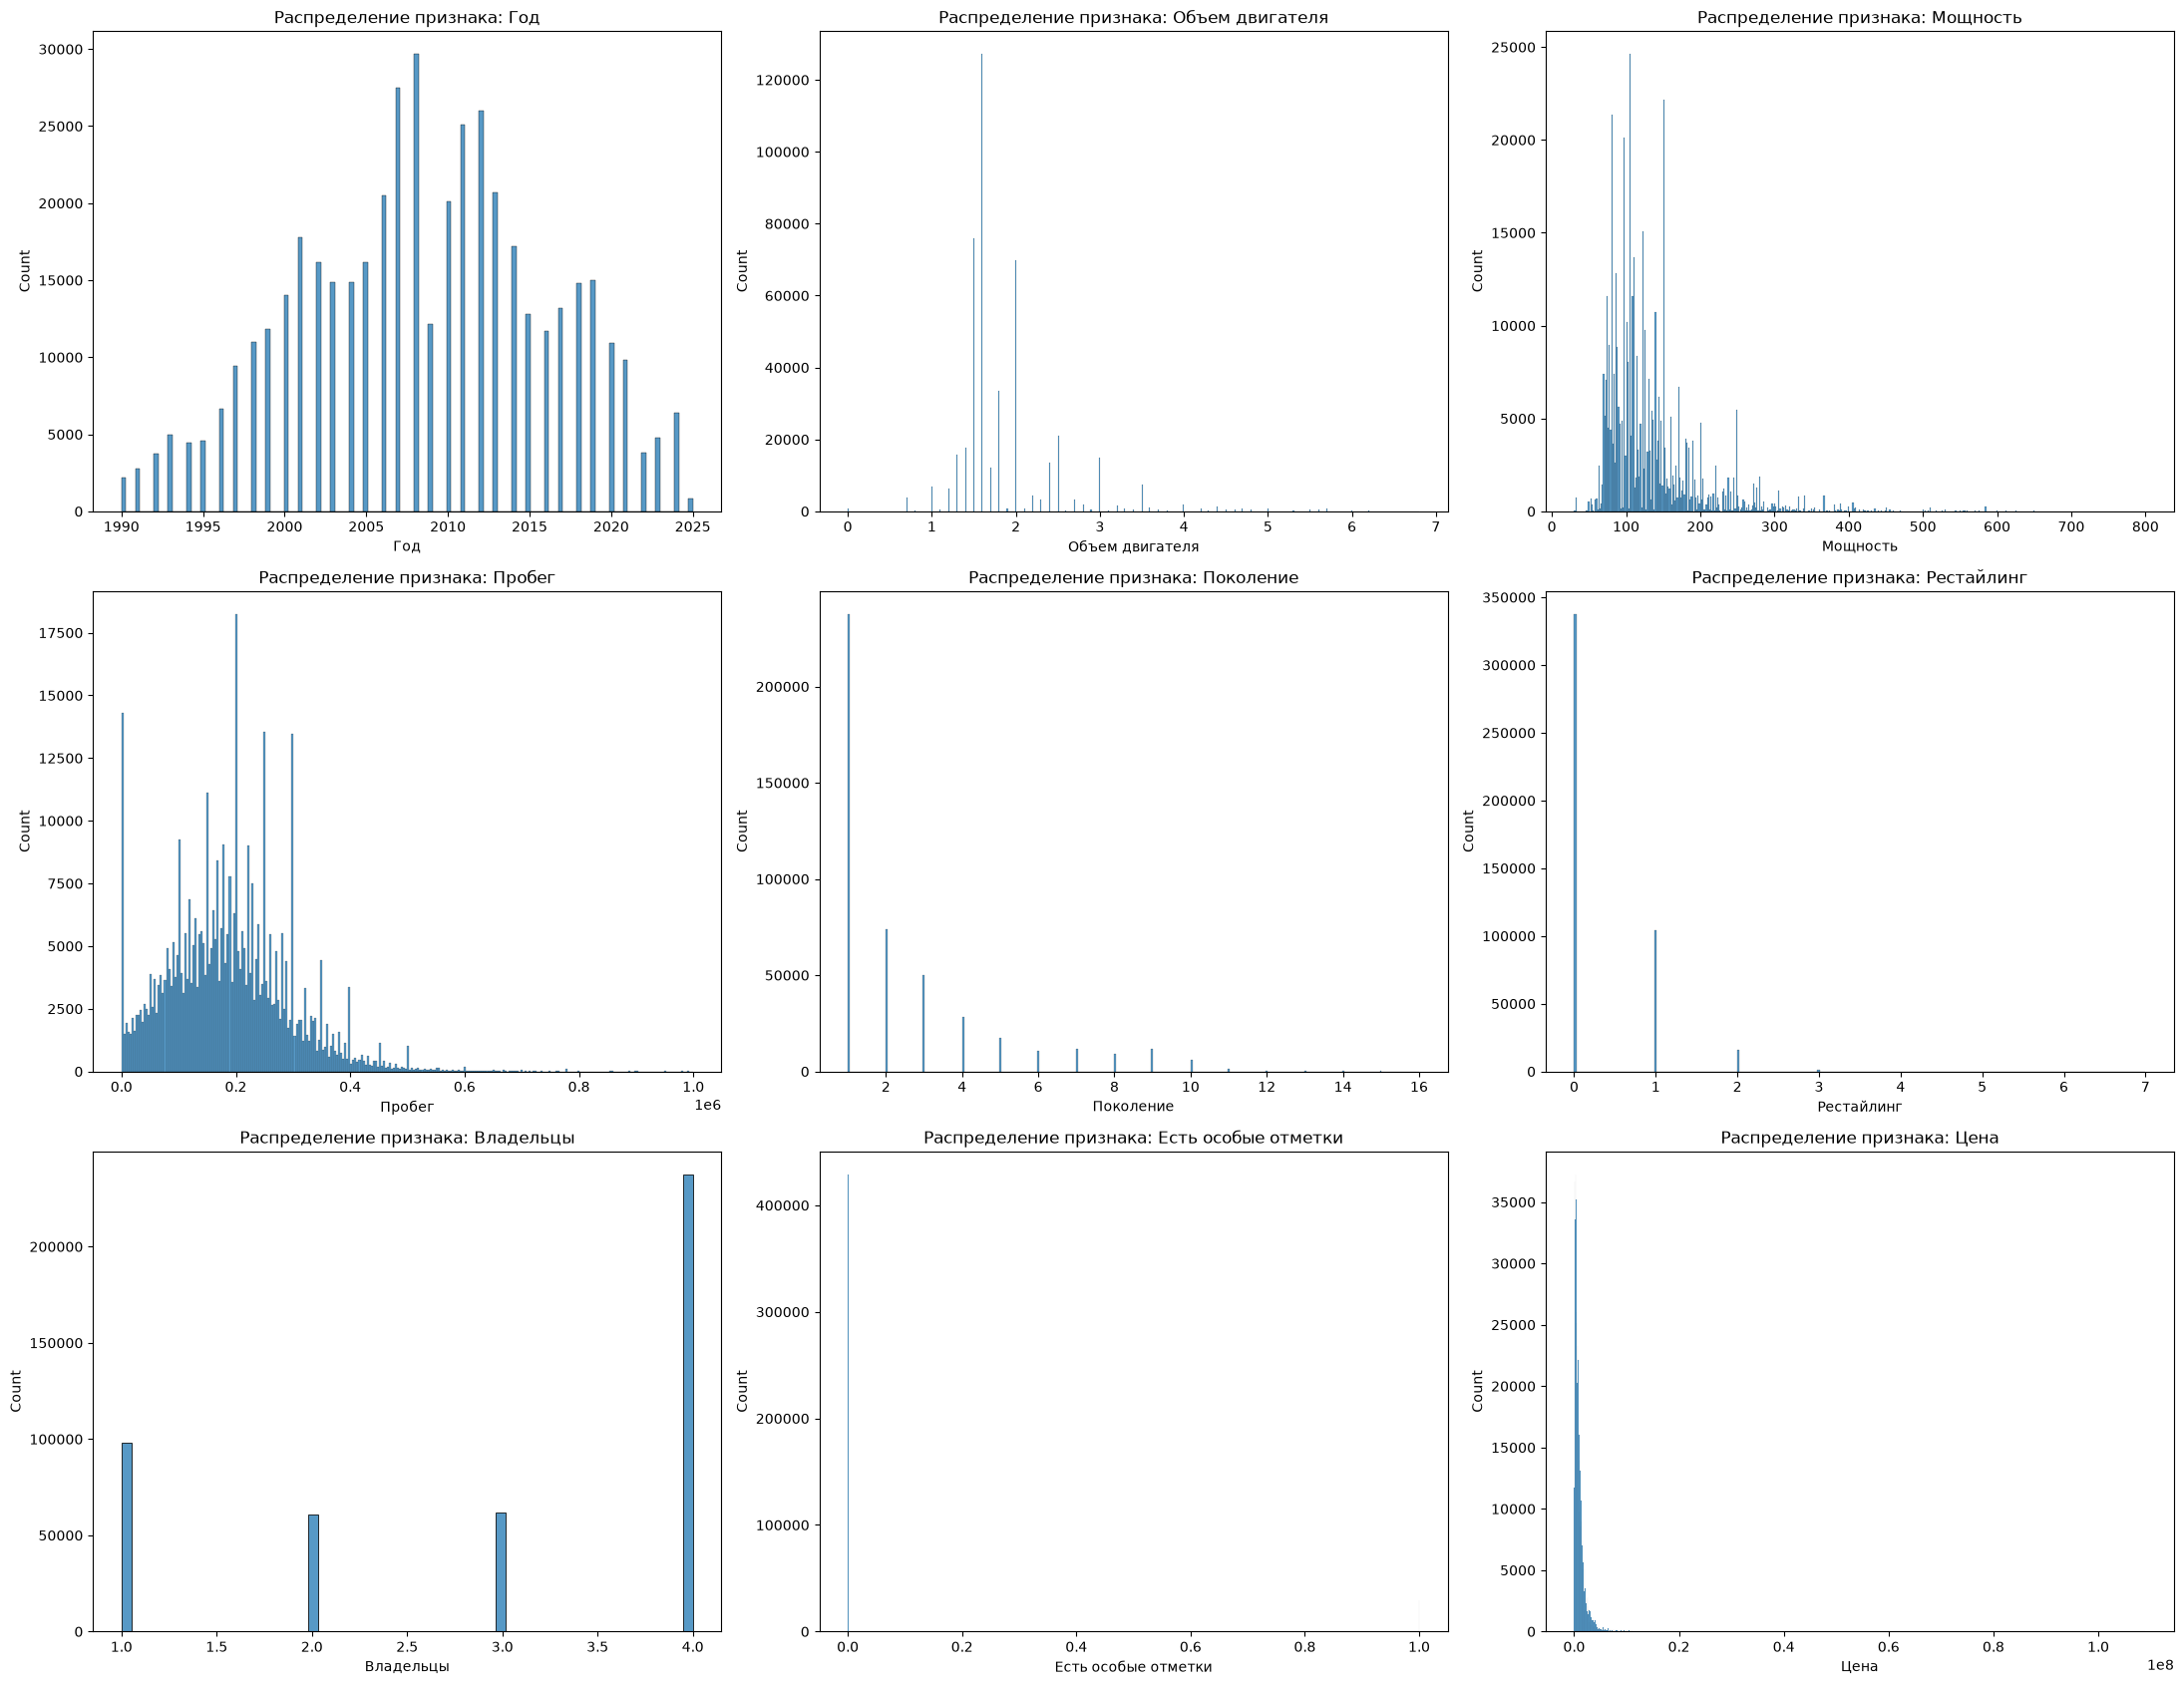

In [119]:
cols_to_plot = num_cols
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(22, 17))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Распределение признака: {col}')
plt.tight_layout()
# Если остались пустые оси - удаляем их
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.show()


Целевая переменная (Цена), а также признаки "Пробег" и "Мощность" имеют выраженную асимметрию с длинными правыми хвостами (несколько экстремально дорогих, мощных машин и машин с огромным пробегом). На этапе Feature Engineering планируется применить логарифмическое преобразование для этих трех признаков, чтобы стабилизировать дисперсию и привести их распределения к более симметричному (близкому к нормальному) виду.

### 4.2 Категориальные признаки

In [120]:
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']


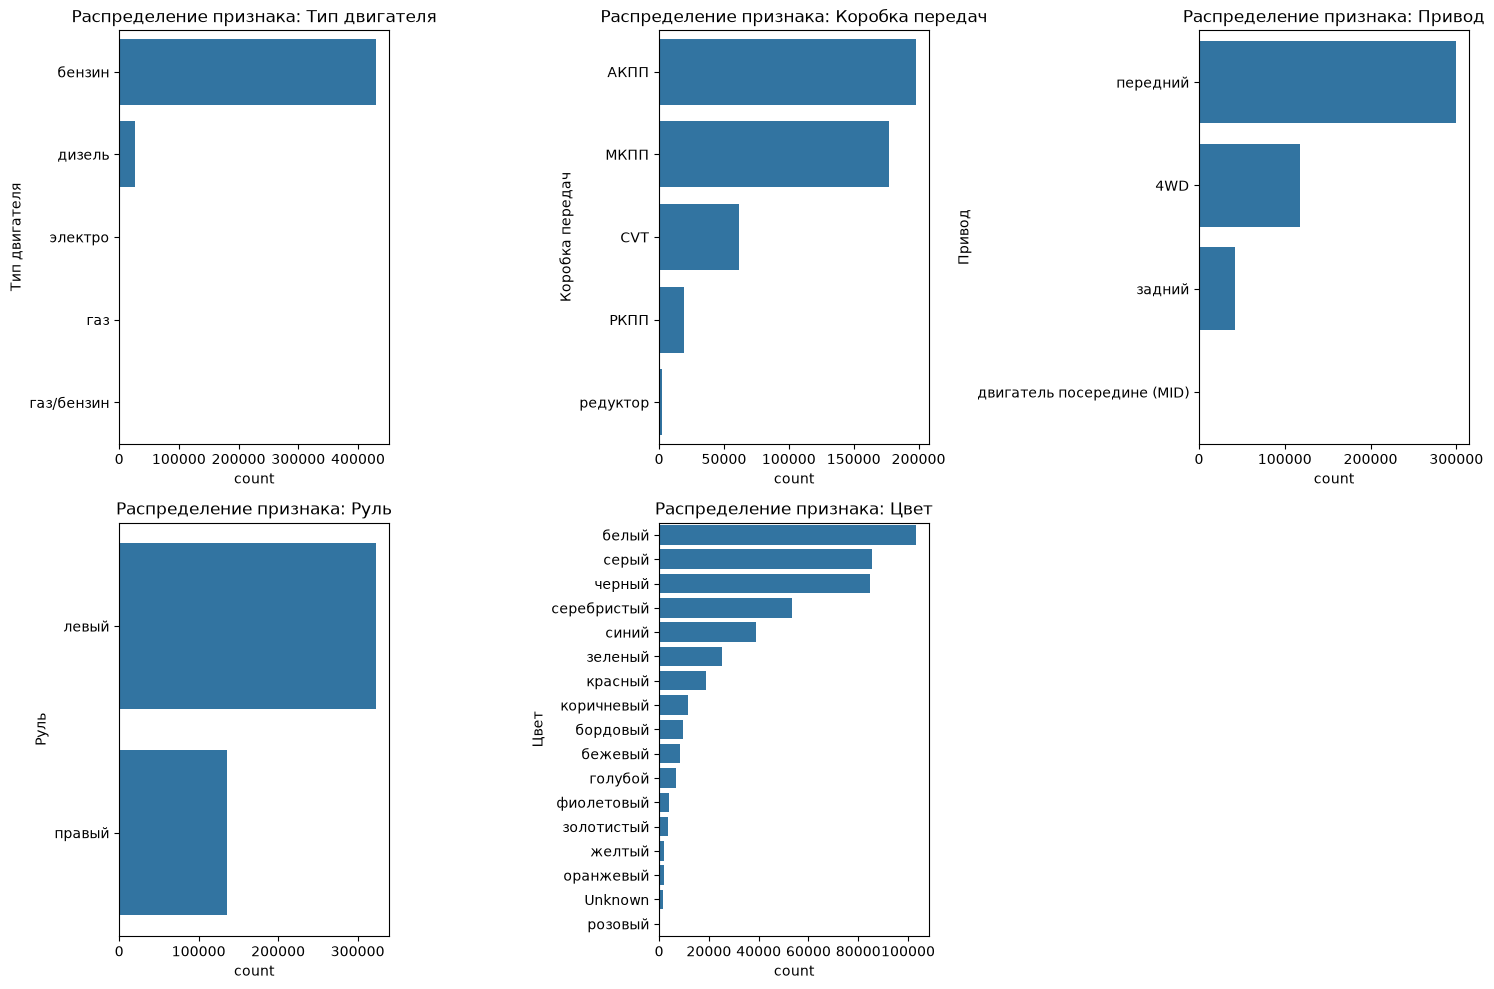

In [121]:
cols_to_plot = cat_cols[1:6]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Распределение признака: {col}')
plt.tight_layout()
# Если остались пустые оси - удаляем их
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.show()


In [122]:
display(df['Город'].value_counts().tail(20))
display(df['Регион'].value_counts().tail(20))
display(df['Макро-регион'].value_counts().head(20))


Город
Хатассы              1
Гапцах               1
Татарская Каргала    1
Мюрего               1
Сапожок              1
Верхнее Казанище     1
Красногородск        1
Староюрьево          1
Хиславичи            1
Старокучергановка    1
Нижний Чир           1
Уразово              1
Синдор               1
Горагорский          1
Холм                 1
Султан-Янги-Юрт      1
Кысыл-Сыр            1
Кикуни               1
Тельмана             1
Колобово             1
Name: count, dtype: int64

Регион
Псковская область                  514
Кабардино-Балкарская Республика    508
Новгородская область               480
Республика Марий Эл                473
Республика Карелия                 467
Республика Коми                    439
Карачаево-Черкесская Республика    279
Республика Калмыкия                 67
Северо-Казахстанская область        11
Ненецкий автономный округ            8
Чукотский автономный округ           7
Западно-Казахстанская область        5
Павлодарская область                 4
Восточно-Казахстанская область       3
Карагандинская область               3
Гродненская область                  2
Гомельская область                   1
Астана                               1
Брестская область                    1
Мангистауская область                1
Name: count, dtype: int64

Макро-регион
СФО                124460
ДФО                 68780
ЮФО                 57412
УрФО                54704
ПФО                 34279
ЦФО                 26164
Новосибирск         25294
Москва              19025
СКФО                15229
Екатеринбург        13458
Санкт-Петербург      7887
СЗФО                 5940
Беларусь             2994
Казань               2819
Казахстан              28
Name: count, dtype: int64

Эти 3 признака сильно коррелируют. Разумнее всего будет оставить лишь Регион - он не такой детальный, как признак Город (в котором есть даже названия посёлков), но и содержит достаточно уникальных значений, в отличие от Макро-региона.

## 5. Двумерный анализ: признаки & таргет

### 5.1 Числовые признаки и таргет

Построим график Цена vs Пробег

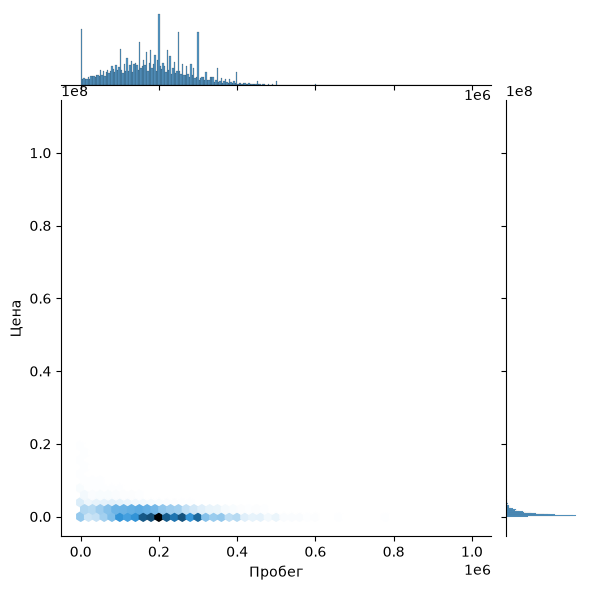

In [123]:
sns.jointplot(kind='hex', data=df, x=df['Пробег'], y=df['Цена'])

Попытка построить связь цены и пробега напрямую. Из-за экстремальных выбросов в ценах (до 100 млн руб.) и пробегах масштаб графика исказился, и 99% данных оказались сплющены внизу у левой оси. Взаимосвязь нечитаема

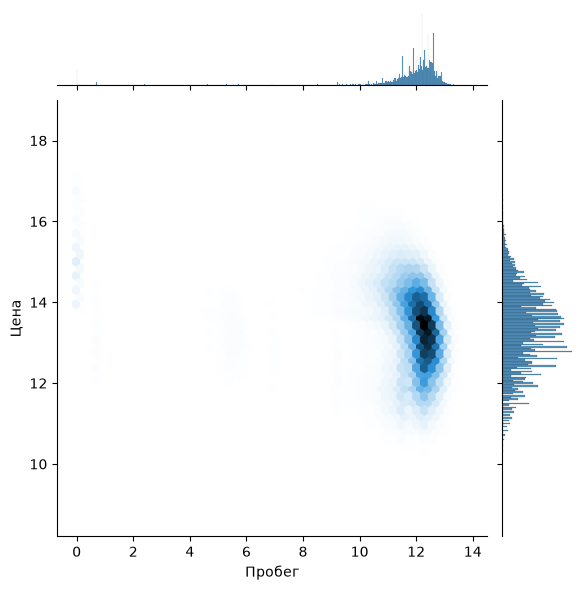

In [124]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Пробег']), y=np.log1p(df['Цена']))

Тот же график после применения логарифмического преобразования log1p к обеим переменным. Масштаб нормализовался, экстремальные значения сгладились. Теперь четко виден отрицательный тренд: с увеличением пробега цена автомобиля закономерно снижается. Исключением являются бледные соты в районе нулевого пробега - это новые машины, и, что логично, они стоят дорого.

Построим график Цена vs Мощность

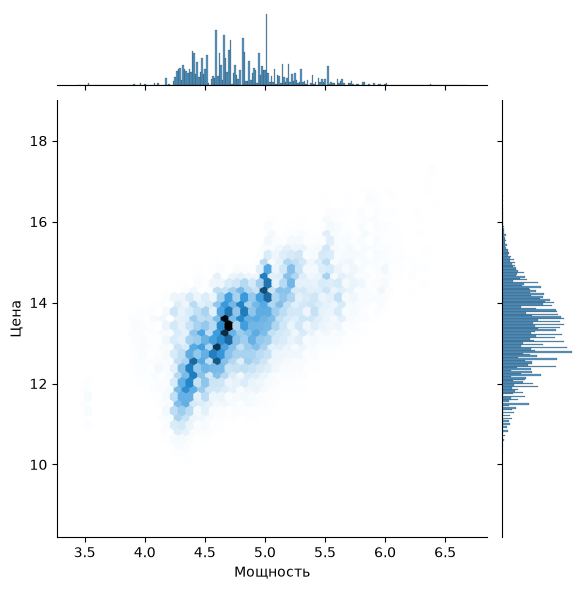

In [125]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Мощность']), y=np.log1p(df['Цена']))

Можем заметить, что чем больше мощность - тем больше цена. Связь линейная. Линейность на лог-шкале указывает на то, что в исходных величинах зависимость носит экспоненциальный характер (каждые дополнительные лошадиные силы дают кратный прирост к цене). Наибольшая плотность объявлений (самый темный сектор) сосредоточена в диапазоне логарифма мощности 4.5–4.8 (что соответствует ~90–120 л.с. в реальных величинах) и логарифма цены 12.5–13.5 (около 270–730 тыс. рублей) - это ядро нашего масс-маркета.

Построим график Цена vs Год

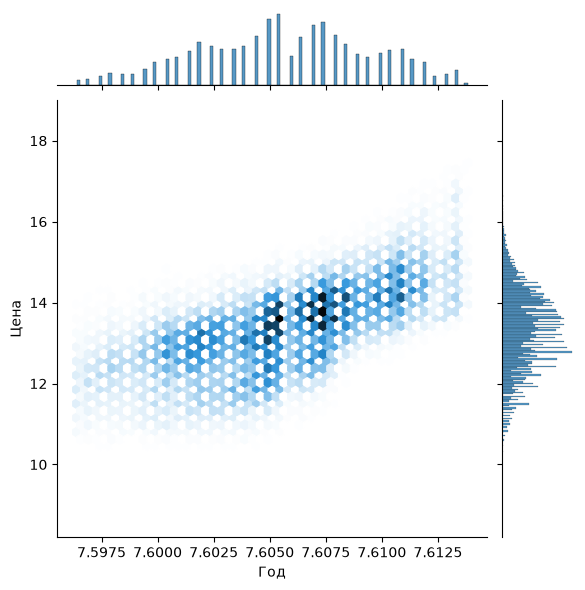

In [126]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Год']), y=np.log1p(df['Цена']))

На графике зависимости цены от года выпуска виден четкий положительный тренд: чем новее автомобиль, тем выше его логарифмическая стоимость.

### 5.2 Категориальные признаки и таргет

По опыту из прошлых графиков, будем использовать только логарифмированную цену для наглядности.

<Axes: xlabel='Коробка передач', ylabel='Цена'>

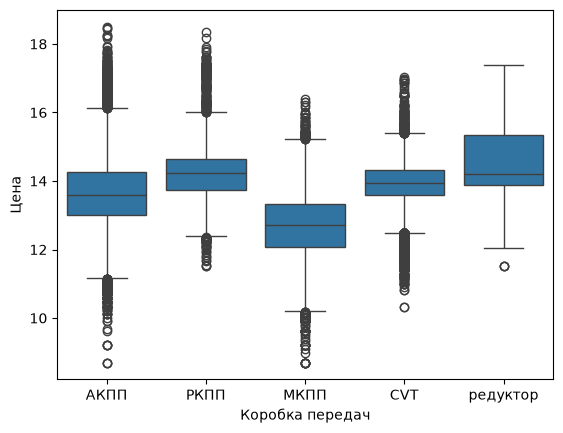

In [127]:
sns.boxplot(x='Коробка передач', y=np.log1p(df['Цена']), data=df)

Можем увидеть, что МКПП имеет самую низкую медианную цену. В то время как редуктор (у электромобилей) цена заметно выше. Это понятно - электромобили на рынке относительно свежие и дорогие, дешевого сегмента у них пока нет.

<Axes: xlabel='Привод', ylabel='Цена'>

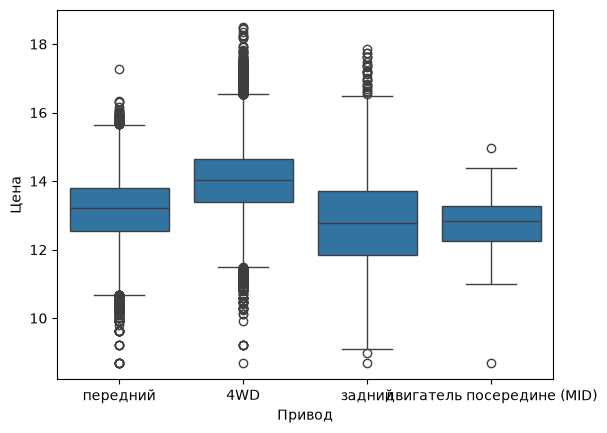

In [128]:
sns.boxplot(x='Привод', y=np.log1p(df['Цена']), data=df)

Заметнны некоторые факты. Во-первых, передний привод - это самый массовых сегмент. В этой категории самые разные машины: от убитых до дорогих. Во-вторых, самая большая медианная цена у полного привода. Это абсолютно логично. Полноприводные машины - это чаще всего кроссоверы, внедорожники и автомобили премиум-класса, которые изначально стоят дороже обычных седанов или хэтчбеков. В-третьих, самый большой разброс цен - у заднего привода. Высота ящика говорит о том, что цены на заднеприводные авто очень сильно варьируются даже внутри основной массы. Секрет прост: в эту категорию одновременно попадают очень дешевые старые машины и весьма дорогие современные автомобили. Из-за этого средняя цена падает (из-за обилия дешевого старья), но разброс цен получается огромным. В-четвёртых, компактность ящика и его "усов" у двигателя посередине говорит нам о том, что, скорее всего, в выборке нет спорткаров (которым как раз и специфичен такой вид привода). но, кажется, есть много недорогих машин (микроавтобусы и тд).

<Axes: xlabel='Тип двигателя', ylabel='Цена'>

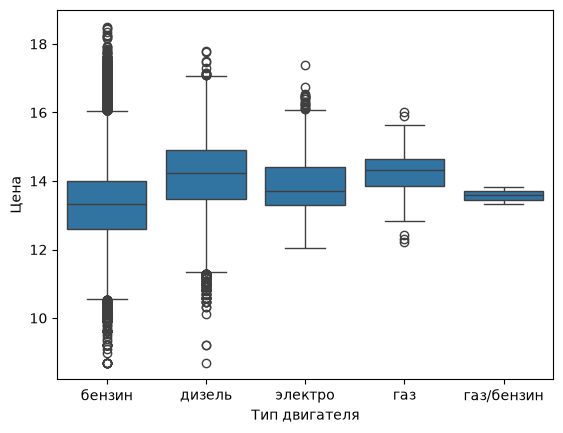

In [129]:
sns.boxplot(x='Тип двигателя', y=np.log1p(df['Цена']), data=df)

Дизельные и чисто газовые автомобили имеют самые высокие медианные цены. Дизель традиционно устанавливается на тяжелую технику, крупные внедорожники и премиальные немецкие автомобили (BMW, Mercedes, Audi). Такие машины изначально намного дороже в производстве и медленнее теряют в цене на вторичном рынке. Бензиновые автомобили имеют самый колоссальный разброс цен и наибольшее количество экстремальных выбросов как в сверхдешевый сегмент, так и в сверхдорогой. Бензин - самое массовое и универсальное топливо. На бензине ездят как и полуубитые "Жигули" за 50 тысяч рублей, так и коллекционные гиперкары за 100 миллионов. Отсюда гигантский разброс цен и обилие выбросов в обе стороны. Признак газ/бензин (битопливные машины) выделяется очень узким ящиком и практически полным отсутствием выбросов. Ставить дорогое газовое оборудование на машины дешевле 150-200 тысяч рублей экономически невыгодно. На дорогие премиум-машины газ тоже практически никто не ставит. Поэтому цены на них зажаты в узком среднем диапазоне. Электромобили имеют высокую медиану , но при этом довольно длинный нижний "ус".  Газ (чистый) - чаще всего это заводские корейские автомобили, которые массово завозятся в страну относительно свежими, что объясняет их высокую медианную цену.

## 6. Взаимодействие признаков

Для начала хочется выкинуть следующие столбцы. Город имеет огромную кардинальность, в то время как Макро-регион содержит не те масштабы, что нужны. Комплектация тоже имеет огромное количество уникальных значений. Большого значения она не несет, так как все признаки у нас уже есть в датасете.

In [130]:
display(df['Регион'].value_counts())

display(df['Макро-регион'].value_counts())
display(df['Город'].value_counts().tail(20))
display(df['Комплектация'].value_counts())

Регион
Краснодарский край       31870
Новосибирск              25294
Приморский край          25114
Иркутская область        24270
Красноярский край        21807
                         ...  
Гродненская область          2
Гомельская область           1
Астана                       1
Брестская область            1
Мангистауская область        1
Name: count, Length: 99, dtype: int64

Макро-регион
СФО                124460
ДФО                 68780
ЮФО                 57412
УрФО                54704
ПФО                 34279
ЦФО                 26164
Новосибирск         25294
Москва              19025
СКФО                15229
Екатеринбург        13458
Санкт-Петербург      7887
СЗФО                 5940
Беларусь             2994
Казань               2819
Казахстан              28
Name: count, dtype: int64

Город
Хатассы              1
Гапцах               1
Татарская Каргала    1
Мюрего               1
Сапожок              1
Верхнее Казанище     1
Красногородск        1
Староюрьево          1
Хиславичи            1
Старокучергановка    1
Нижний Чир           1
Уразово              1
Синдор               1
Горагорский          1
Холм                 1
Султан-Янги-Юрт      1
Кысыл-Сыр            1
Кикуни               1
Тельмана             1
Колобово             1
Name: count, dtype: int64

Комплектация
1.5 MT Базовая                                                                                                                                                                                                           3933
1.6 MT 21074-30-011//1.6 MT 21074-30-012//1.6 MT 21074-30-012 Стандарт//1.6 MT 21074-30-013//1.6 MT 21074-30-013 Стандарт//1.6 MT 21074-30-015 Стандарт//1.6 MT 21074-40-013//1.6 MT 21074-40-015                        3208
1.5i MT Базовая                                                                                                                                                                                                          2943
1.6 MT Базовая 5-дв. 21124                                                                                                                                                                                               2666
1.6 MT Comfort                                                                                     

In [131]:
df = df.drop(columns=['Комплектация', 'Макро-регион', 'Город'])

Сразу подмечу: матрица корреляций phik работает иначе, чем, например, Пирсона. Она раскидывает значения от 0 до 1 (без отрицательных значений).

c:\Users\Степан\AppData\Local\Programs\Python\Python314\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable Название машины is large: 1521. Are you sure this is not an interval variable? Analysis for pairs of variables including Название машины can be slow.
  warnings.warn(


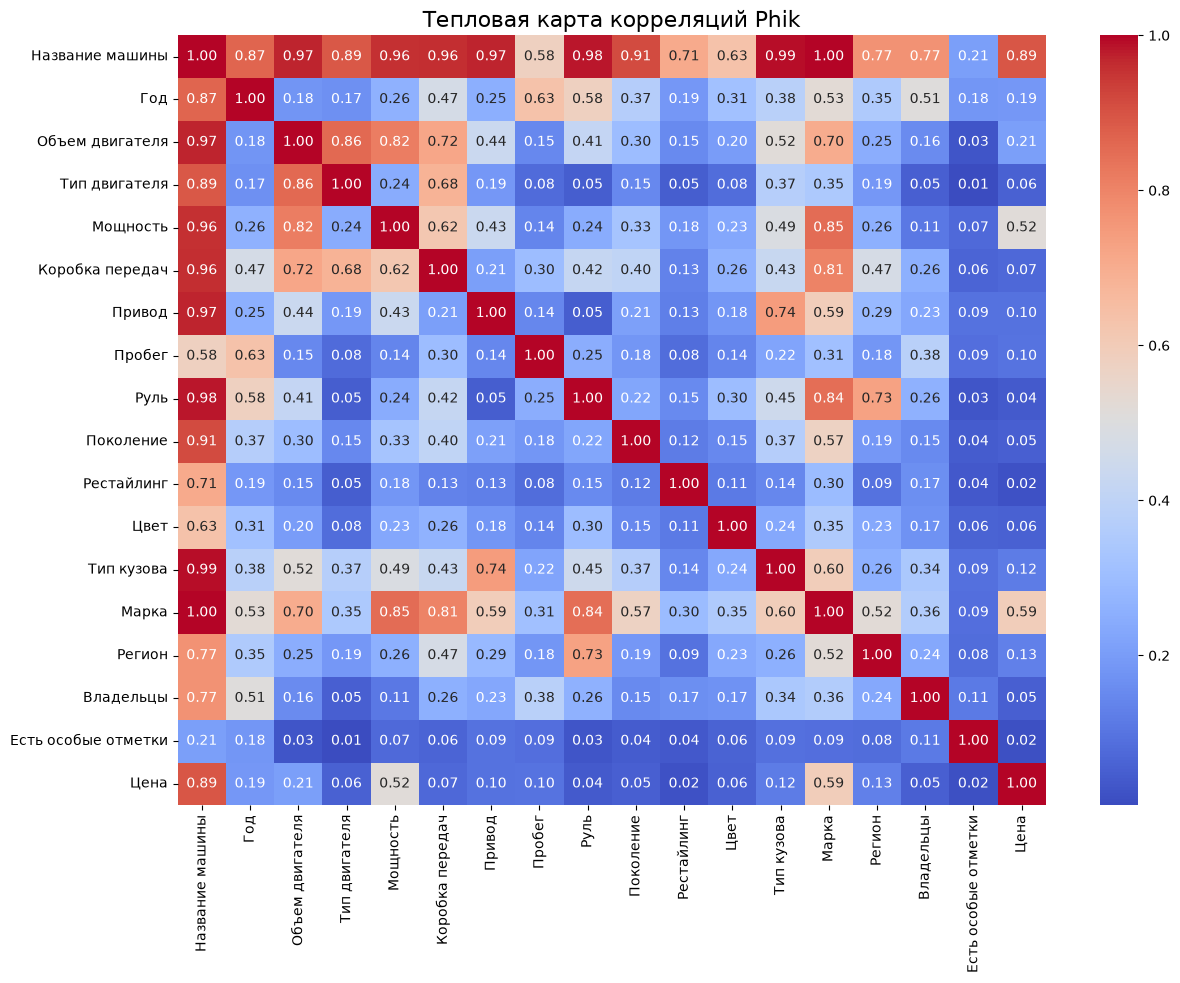

In [132]:
plt.figure(figsize=(14, 10)) 
phik_matrix = df.phik_matrix(interval_cols=num_cols)
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Тепловая карта корреляций Phik', fontsize=16)
plt.show()

Важное примечание по интерпретации: На тепловой карте Phik наблюдаются аномально высокие показатели корреляции для признака "Название машины" со всеми фичами (включая регион, количество владельцев и тип кузова). Это математическая особенность коэффициента Phik, который переоценивает связь для категориальных признаков с высокой кардинальностью (большим числом уникальных категорий). В реальности настолько сильной линейной или нелинейной зависимости с этими признаками нет. На этапе FE планируется:
1. "Высечь" из названия машины модель (так как признак "Марка" уже есть). Разделив название машины на марку и модель, мы уберём дублирование информации, поможем модели находить скрытые взаимосвязи и защитим ее от провала на новых данных. 
2. Для работы с высококардинальным признаком "Модель" планируется применить целевое кодирование (Target Encoding) / частотное кодирование / встроенные механизмы обработки категорий в CatBoost.

## 7. Feature Engineering

In [134]:
df['Название машины'] = df['Название машины'].astype(str)
df['Марка'] = df['Марка'].astype(str)
def extract_model(row):
    full_name = row['Название машины']
    # Нормализуем исходную марку (например, "aston_martin" -> "aston martin")
    brand_raw = row['Марка'].lower().replace('_', ' ')
    full_name_lower = full_name.lower()
    
    # 1. Словарь синонимов для брендов, которые могут быть написаны по-русски
    brand_synonyms = {
        'lada': ['лада'],
        'uaz': ['уаз'],
        'gaz': ['газ'],
        'moskvich': ['москвич'],
    }
    
    # 2. Получаем список возможных написаний для текущей марки.
    # Если марки нет в словаре синонимов, используем только саму марку (в списке).
    possible_names = brand_synonyms.get(brand_raw, [brand_raw])
    
    # 3. Проверяем каждый синоним по очереди
    for name in possible_names:
        if full_name_lower.startswith(name):
            # Как только нашли совпадение, отрезаем его длину от оригинального названия
            return full_name[len(name):].strip()
            
    # Если совпадений вообще не нашлось (например, написано просто "Гранта")
    return full_name

# Применяем новую функцию
df['Модель'] = df.apply(extract_model, axis=1)

# Удаляем старую колонку
df = df.drop(columns=['Название машины'])